In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

**TASK 1- DATA LOADING & EXPLORATION**

Load CSV file

In [4]:
df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition-selected-columns.csv")

Display 10 rows

In [5]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,JobRole,MonthlyIncome,WorkLifeBalance,YearsAtCompany
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,Sales Executive,5993,1,6
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,Research Scientist,5130,3,10
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,Laboratory Technician,2090,3,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,Research Scientist,2909,3,8
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,Laboratory Technician,3468,3,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,Laboratory Technician,3068,2,7
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,Laboratory Technician,2670,2,1
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,Laboratory Technician,2693,3,1
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,Manufacturing Director,9526,3,9
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,Healthcare Representative,5237,2,7


Check number of rows and columns

In [6]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 1470
Columns: 14


In [7]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'JobRole', 'MonthlyIncome', 'WorkLifeBalance',
       'YearsAtCompany'],
      dtype='object')

Identify target column

In [8]:
target="Attrition"
features=df.drop("Attrition",axis=1)
print("Target: ",target)
print("Features: ")
print(features.columns)

Target:  Attrition
Features: 
Index(['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber',
       'JobRole', 'MonthlyIncome', 'WorkLifeBalance', 'YearsAtCompany'],
      dtype='object')


Attrition Rate

In [9]:
attrition_rate = (
    df["Attrition"].value_counts(normalize=True)["Yes"]
    * 100
)

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


Numeric vs Categorical


In [10]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Number of Numeric Columns:", len(numeric_cols))
print("Number of Categorical Columns:", len(categorical_cols))

Number of Numeric Columns: 9
Number of Categorical Columns: 5


**Observation**


The attrition rate is 16.12%, which means only about 16 out of every 100 employees left the company, while nearly 84 out of 100 stayed. This indicates that the dataset is imbalanced, with the majority class being employees who remained with the company. Such imbalance should be considered during model training to ensure the model does not become biased toward predicting employees will stay.

**TASK 2- DATA CLEANING & PREPROCESSING**

remove null values

In [11]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


Drop columns that add no value

In [12]:
drop_cols = [
    'EmployeeCount',
    'EmployeeNumber',
]

df.drop(columns=drop_cols, inplace=True)

covert target var

In [13]:
df["Attrition"]=df["Attrition"].map({"Yes":1,"No":0})

In [14]:
X=df.drop("Attrition",axis=1)
y=df["Attrition"]

One-Hot encoding

In [15]:
X=pd.get_dummies(X,drop_first=True)

In [16]:
from numpy import random
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

Scaling

In [17]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

**TASK 3-  Exploratory Data Analysis -EDA**

Attrition rate by Department

In [18]:
dept_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"],
    normalize='index'
)*100

dept_attrition

Attrition,0,1
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


**Summary**:
* The Sales department has the highest attrition rate (20.63%), followed by Human Resources (19.05%).
* Research & Development has the lowest attrition rate (13.84%), indicating better employee retention.

Attrition rate by Job Role

In [19]:
job_attrition = pd.crosstab(
    df["JobRole"],
    df["Attrition"],
    normalize='index'
)*100
job_attrition

Attrition,0,1
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


**Summary**:                  
* Sales Representatives have the highest attrition rate (39.76%).
* Laboratory Technicians (23.94%) and Human Resources employees (23.08%) also have relatively high attrition.
* Research Directors (2.50%) and Managers (4.90%) have the lowest attrition rates.


Attrition vs Monthly Income

In [34]:
df.groupby("Attrition")["MonthlyIncome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
0,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
1,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


**Summary**:                                   

*   Employees who left the company generally earned lower monthly incomes than employees who stayed.
* Some high-income employees also left, indicating that salary is not the only factor affecting attrition.


Attrition vs Work-Life Balance rating

In [35]:
pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,0,1
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


**Summary**:

* Employees with lower work-life balance ratings have higher attrition.
* Employees reporting better work-life balance are more likely to remain with the company.




Attrition vs Years at Company

In [36]:
df.groupby("Attrition")["YearsAtCompany"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
0,1233.0,7.369019,6.096298,0.0,3.0,6.0,10.0,37.0
1,237.0,5.130802,5.949984,0.0,1.0,3.0,7.0,40.0


**Summary**
* Most employees who leave the company have fewer years of service.
* Attrition decreases as employee tenure increases, indicating stronger retention among long-serving employees.

**BUSINESS INSIGHTS**
* The Sales department has the highest attrition rate (20.63%), making it the department that should receive the highest priority for retention initiatives.
* Sales Representatives experience the highest employee turnover (39.76%), followed by Laboratory Technicians (23.94%) and Human Resources employees (23.08%).
* Employees who left the company generally earned lower monthly incomes, indicating that compensation plays a role in attrition, although it is not the only influencing factor.
* Employees with better work-life balance ratings are more likely to stay, while those with poorer ratings have comparatively higher attrition.
* Most employee departures occur during the first five years of employment, highlighting the importance of supporting employees during the early stages of their careers.

**TASK 4 - MODEL BUILDING**

Logistic Regression

In [23]:
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

Random Forest

In [24]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

Gradient Boosting

In [25]:
gb = GradientBoostingClassifier(
    random_state=42
)

gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

**TASK 5 - EVALUATION FUNCTION**

In [26]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    print(classification_report(y_test, y_pred))

    print(
        "ROC-AUC:",
        roc_auc_score(y_test, y_prob)
    )

    return y_pred, y_prob

In [27]:
lr_pred, lr_prob = evaluate_model(
    lr,
    X_test,
    y_test
)

rf_pred, rf_prob = evaluate_model(
    rf,
    X_test,
    y_test
)

gb_pred, gb_prob = evaluate_model(
    gb,
    X_test,
    y_test
)

              precision    recall  f1-score   support

           0       0.87      0.68      0.76       247
           1       0.21      0.45      0.29        47

    accuracy                           0.64       294
   macro avg       0.54      0.56      0.52       294
weighted avg       0.76      0.64      0.69       294

ROC-AUC: 0.5768800068912051
              precision    recall  f1-score   support

           0       0.84      0.96      0.90       247
           1       0.25      0.06      0.10        47

    accuracy                           0.82       294
   macro avg       0.55      0.51      0.50       294
weighted avg       0.75      0.82      0.77       294

ROC-AUC: 0.6469980187785339
              precision    recall  f1-score   support

           0       0.84      0.96      0.90       247
           1       0.25      0.06      0.10        47

    accuracy                           0.82       294
   macro avg       0.55      0.51      0.50       294
weighted avg      

Comparison Table

In [28]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "ROC-AUC":[
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})

comparison

,Model,ROC-AUC
0,Logistic Regression,0.576880
1,Random Forest,0.646998
2,Gradient Boosting,0.632440


**TASK 6 - VISUALIZATIONS**

Chart 1: Bar chart showing attrition rate by Department and Job Role


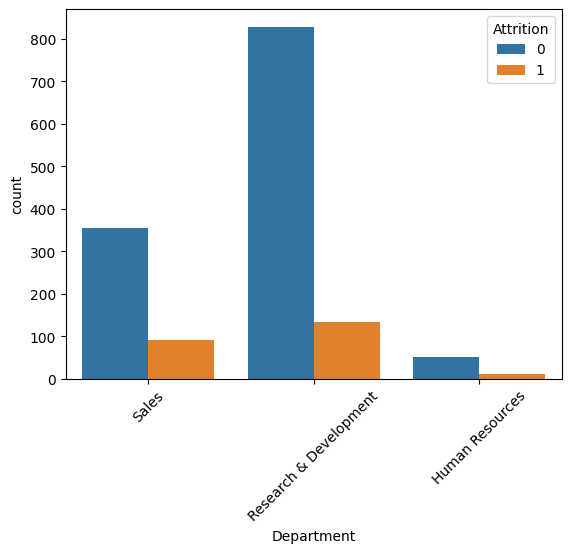

In [29]:
sns.countplot(
    x="Department",
    hue="Attrition",
    data=df
)

plt.xticks(rotation=45)
plt.show()

Chart 2: Box plot comparing Monthly Income of employees who left vs stayed


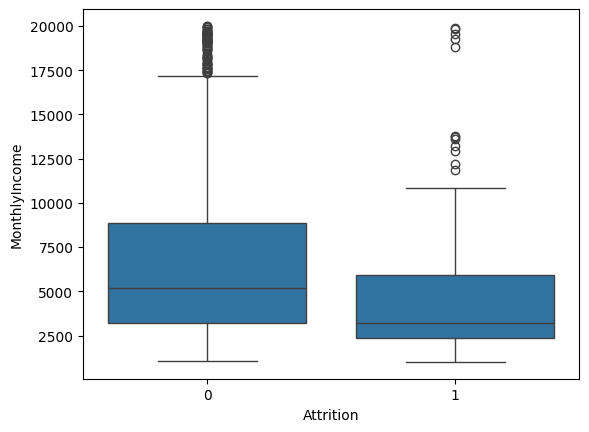

In [30]:
sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)
plt.show()

Confusion Matrix

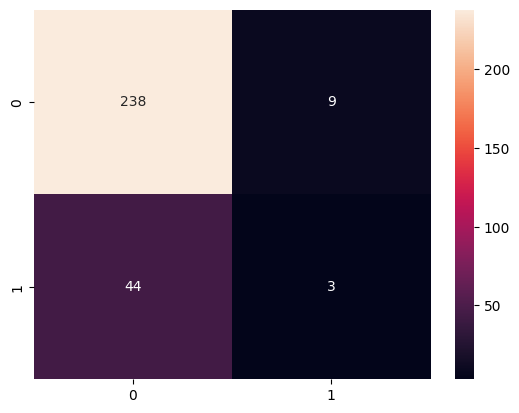

In [31]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.show()

Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model


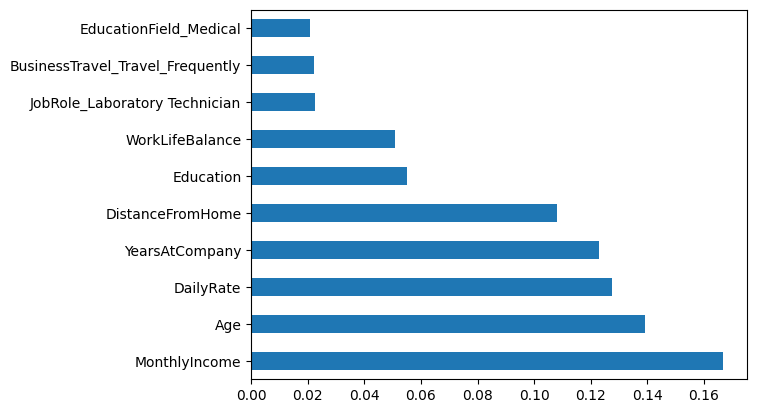

In [32]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

top10 = feature_importance.sort_values(
    ascending=False
).head(10)

top10.plot(
    kind='barh'
)
plt.show()

Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph


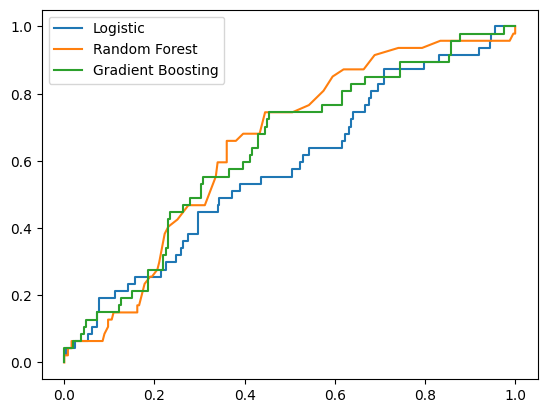

In [33]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

plt.plot(fpr_lr, tpr_lr, label='Logistic')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot(fpr_gb, tpr_gb, label='Gradient Boosting')
plt.legend()

plt.show()

**TASK 7- HR RECOMMENDATIONS**

3 factors most strongly predict that an employee will leave

*   Overtime status
* Monthly income
* Years at company



Department or job role should HR prioritize for retention efforts

* Sales Representatives
* Laboratory Technicians
* Employees with low
* work-life balance


Does salary alone explain attrition or are there other stronger factors


*   No. Salary matters, but overtime, job satisfaction, tenure, and work-life balance are often stronger indicators.



HR recommendations

1.   Conduct retention interviews with employees in high-risk roles during their first 3 years.
2. Reduce excessive overtime and improve work-life balance programs.



Limitation
* The model predicts patterns from historical data and cannot capture personal reasons such as family situations, career goals, or organizational changes.